# Install Required Libraries

In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn wordcloud

Note: you may need to restart the kernel to use updated packages.


# Load the Data

In [2]:
import pandas as pd

# Load CSV file
df = pd.read_csv('training.1600000.processed.noemoticon.csv', encoding='latin-1', header=None)

# Assign column names
df.columns = ['target', 'ids', 'date', 'flag', 'user', 'text']

# Show first few rows
df.head()


,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


# Keep Relevant Columns & Relabel Sentiment

In [3]:
# Keep only target and text columns
df = df[['target', 'text']]

# Map 0 (negative), 4 (positive) to 0 and 1
df['target'] = df['target'].map({0: 0, 4: 1})

# Preview
df.head()


,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


# Clean the Tweets

In [4]:
import re

def clean_text(text):
    text = re.sub(r"http\S+", "", text)            # remove URLs
    text = re.sub(r"@\w+", "", text)               # remove @mentions
    text = re.sub(r"#", "", text)                  # remove # (keep word)
    text = re.sub(r"[^A-Za-z\s]", "", text)        # remove special characters
    text = re.sub(r"\s+", " ", text)               # remove extra spaces
    return text.lower().strip()

# Apply cleaning
df['clean_text'] = df['text'].apply(clean_text)

# Preview
df[['text', 'clean_text']].head()


,text,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww thats a bummer you shoulda got david carr...
1,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i her...


# Drop Duplicates and Nulls

In [5]:
# Drop duplicate tweets
df.drop_duplicates(subset='clean_text', inplace=True)

# Drop rows with empty clean_text
df = df[df['clean_text'].str.strip() != '']

# Reset index
df.reset_index(drop=True, inplace=True)

# Final shape
df.shape


(1518633, 3)

# Exploratory Data Analysis (EDA)

### Visualize Sentiment Distribution

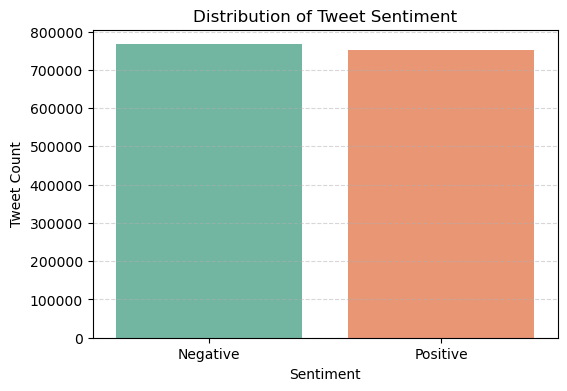

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Countplot
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title("Distribution of Tweet Sentiment")
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.xlabel("Sentiment")
plt.ylabel("Tweet Count")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Word Cloud for Each Sentiment

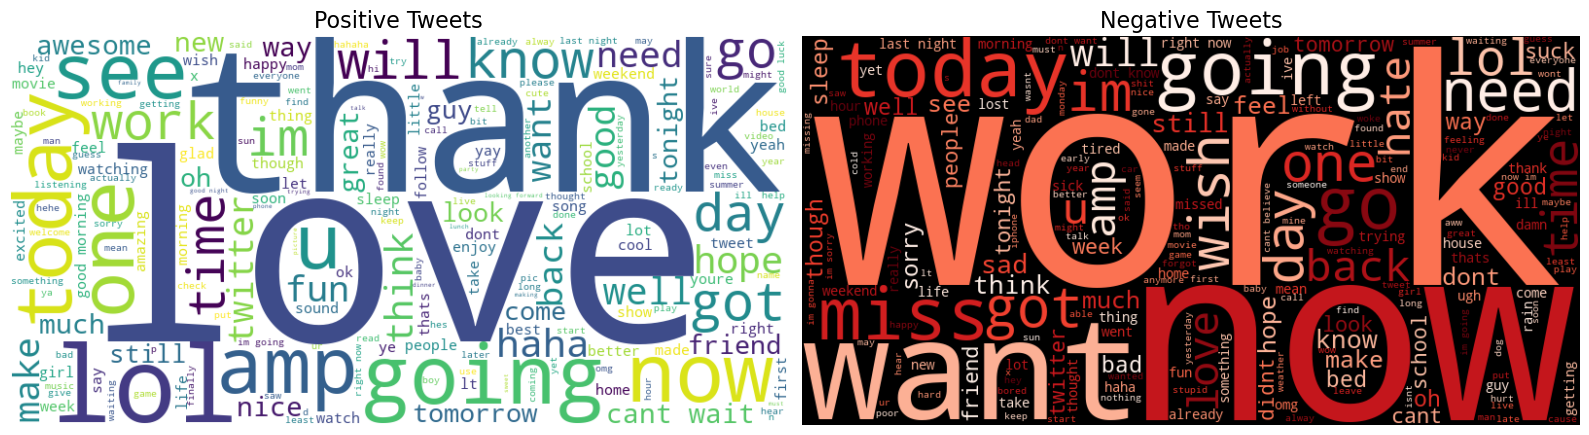

In [7]:
from wordcloud import WordCloud

# Separate positive and negative text
pos_text = " ".join(df[df['target'] == 1]['clean_text'])
neg_text = " ".join(df[df['target'] == 0]['clean_text'])

# Word clouds
plt.figure(figsize=(16,8))

# Positive
plt.subplot(1, 2, 1)
wc_pos = WordCloud(width=800, height=400, background_color='white').generate(pos_text)
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Tweets", fontsize=16)

# Negative
plt.subplot(1, 2, 2)
wc_neg = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(neg_text)
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Tweets", fontsize=16)

plt.tight_layout()
plt.show()


# Top 20 Common Words in All Tweets

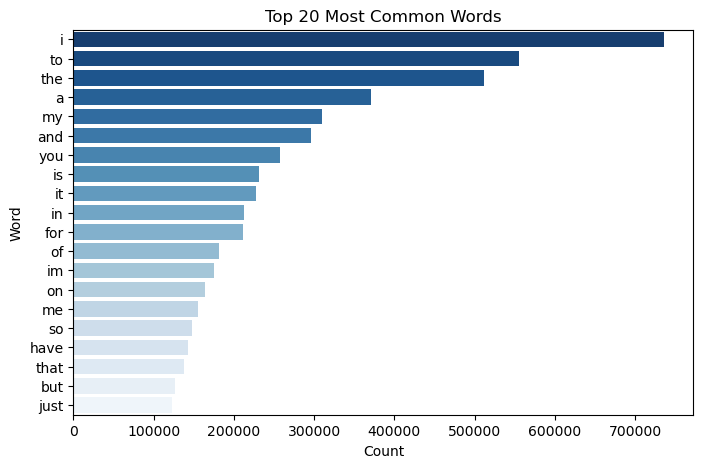

In [9]:
from collections import Counter

# Tokenize all clean text
all_words = " ".join(df['clean_text']).split()
common_words = Counter(all_words).most_common(20)

# Convert to DataFrame and plot
word_freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

# Bar plot
plt.figure(figsize=(8,5))
sns.barplot(x='Frequency', y='Word', data=word_freq_df, palette='Blues_r')
plt.title("Top 20 Most Common Words")
plt.xlabel("Count")
plt.ylabel("Word")
plt.show()

# TF-IDF Vectorization

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF
tfidf = TfidfVectorizer(max_features=5000)

# Fit and transform
X = tfidf.fit_transform(df['clean_text'])  
y = df['target']

# Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Models

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Support Vector Machine": LinearSVC()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.7855
Naive Bayes Accuracy: 0.7631


C:\Users\jomol\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Support Vector Machine Accuracy: 0.7846


# Hyperparameter Tuning

# Set Up GridSearchCV

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']  # for small datasets and binary classification
}

# Initialize base model
lr = LogisticRegression(max_iter=1000)

# Grid search setup
grid = GridSearchCV(estimator=lr, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)

# Fit to training data
grid.fit(X_train, y_train)


Fitting 3 folds for each of 4 candidates, totalling 12 fits


GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear']},
             verbose=1)

# Print Best Parameters & Accuracy

In [15]:
print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Score:", grid.best_score_)

Best Parameters: {'C': 1, 'solver': 'liblinear'}
Best Cross-Validation Score: 0.7867225948051271


# Evaluate on Test Set

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict with best model
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

# Confusion matrix and report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[118471  34655]
 [ 30476 120125]]
              precision    recall  f1-score   support

           0       0.80      0.77      0.78    153126
           1       0.78      0.80      0.79    150601

    accuracy                           0.79    303727
   macro avg       0.79      0.79      0.79    303727
weighted avg       0.79      0.79      0.79    303727

